# M2-B1 — Audit Banque Eckmühl + industrialisation pipe

> **Mission** : auditer le dataset German Credit fourni par Eckmühl, identifier
> les risques qualité et éthiques, construire un Pipeline scikit-learn
> réutilisable, persister en Parquet, documenter dans une datasheet.

Auteur·rice : `Tom Carpentier` — Date : `16/06/2026`

**Conventions** :
- `random_state=42` partout
- Pas de `print` (utiliser `display()` ou laisser la cellule retourner)
- `pathlib.Path` sur les chemins

## 0. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RANDOM_STATE = 42
DATA_DIR = Path("../data")
RAW_PATH = DATA_DIR / "german_credit_raw.csv"
CLEAN_PATH = DATA_DIR / "german_credit_clean.parquet"

sns.set_theme(style="whitegrid")

## 1. Découverte du dataset (~30 min)

Chargement, types, premier aperçu. Repérage de la cible et des variables
sensibles évidentes (`age`, `personal_status_sex`, `foreign_worker`).

In [2]:
df = pd.read_csv(RAW_PATH)

# Cible
display(df["credit_risk"].value_counts(normalize=True).rename("proportion").to_frame())

# Variables sensibles - age, personal_status_sex, foreign_worker
sensitive = ["age", "personal_status_sex", "foreign_worker"]
for col in sensitive: 
    display(df[col].value_counts().rename(col).to_frame())

,proportion
credit_risk,
good_credit,0.7
bad_credit,0.3


,age
age,
27,51
26,50
23,48
24,44
28,43
25,41
30,40
35,40
36,39


,personal_status_sex
personal_status_sex,
male single,548
female divorced/separated/married,310
male married/widowed,92
male divorced/separated,50


,foreign_worker
foreign_worker,
yes,963
no,37


**Observation** : `personal_status_sex` mélange genre et statut marital dans une seule variable composite. 
`foreign_worker` présente un fort déséquilibre (963 yes vs 37 no).

## 2. Audit qualité (~1 h)

Manquants, outliers, types, cohérence des modalités. **Au moins 4
visualisations** : distribution cible, distribution `age`, distribution
`credit_amount`, crosstab sensible (ex. `credit_risk` × `personal_status_sex`).

> *Problèmes de qualité identifiés*

**Valeurs manquantes** : aucune valeur manquante  
**Valeurs atypiques** : valeurs atypiques détectées dans la varaible credit_amount  
**Variable composite** : la variable personal_status_sex est un mélange entre le genre et le statut marital. Impossible d'isoler l'effet du genre seul.  
**Déséquilibre** : déséquilibre sur la varaible foreign_worker, 96% de dossiers sont à des résidents non-étrangers. Déséquilibre de la variable cible : 70% de "bon crédit", 30% de "mauvais crédit"

In [18]:
# Manquants
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame(
    {"count": missing, "pct": missing_pct}
).sort_values("pct", ascending=False)

display(missing_df[missing_df["count"] > 0])


,count,pct


Aucune colonne manquante.

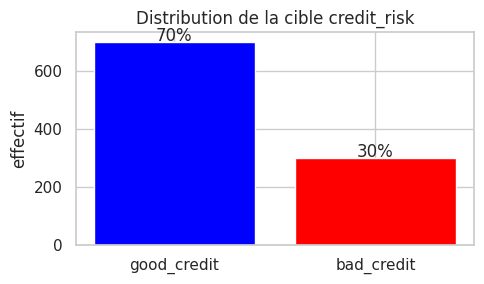

In [38]:
# Distribution de la cible
fig, ax = plt.subplots(figsize=(5,3))
counts = df["credit_risk"].value_counts()
ax.bar(counts.index, counts.values, color=["blue", "red"])
ax.set_title("Distribution de la cible credit_risk")
ax.set_ylabel("effectif")
for i, (label, val) in enumerate(counts.items()):
    ax.text(i, val + 5, f"{val/len(df)*100:.0f}%", ha="center")
plt.tight_layout()
plt.show()

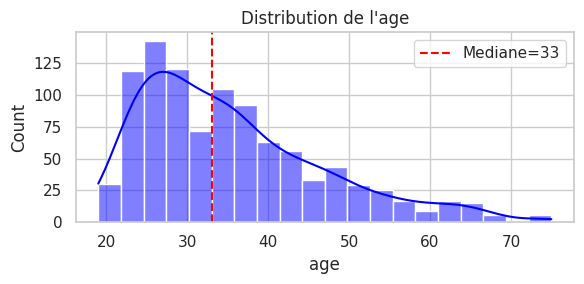

In [24]:
# Distribution de age
fig, ax = plt.subplots(figsize=(6,3))
sns.histplot(df["age"], bins=20, kde=True, ax=ax, color="blue")
ax.axvline(df["age"].median(), color="red", linestyle="--", label=f"Mediane={df['age'].median():.0f}")
ax.set_title("Distribution de l'age")
ax.legend()
plt.tight_layout()
plt.show()

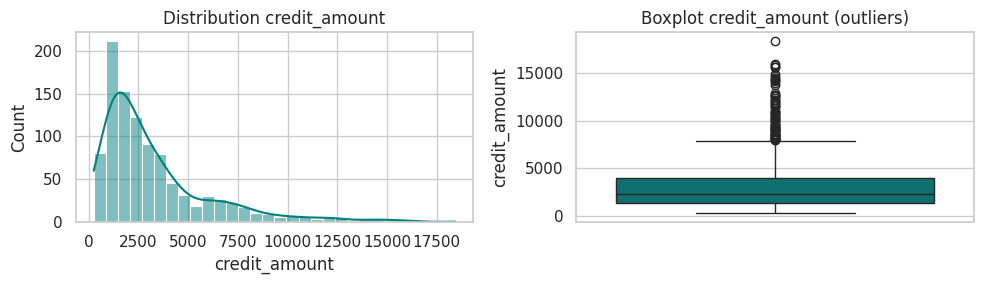

In [27]:
# Distribution de credit_amount (avec outliers)
fig, axes = plt.subplots(1, 2, figsize=(10,3))

sns.histplot(df["credit_amount"], bins=30, kde=True, ax=axes[0], color="teal")
axes[0].set_title("Distribution credit_amount")

sns.boxplot(y=df["credit_amount"], ax=axes[1], color="teal")
axes[1].set_title("Boxplot credit_amount (outliers)")

plt.tight_layout()
plt.show()

On observe des outliers dans les données de la colonne credit_amount.

In [30]:
# Détection outliers IQR - la valeur de 1.5 est choisi arbitrairement
q1, q3 = df["credit_amount"].quantile([0.25, 0.75])
iqr = q3 - q1
n_outliers = ((df["credit_amount"] < q1 - 1.5 * iqr) | (df["credit_amount"] > q3 + 1.5 * iqr)).sum()
print(f"{n_outliers} outliers IQR détectés")

72 outliers IQR détectés


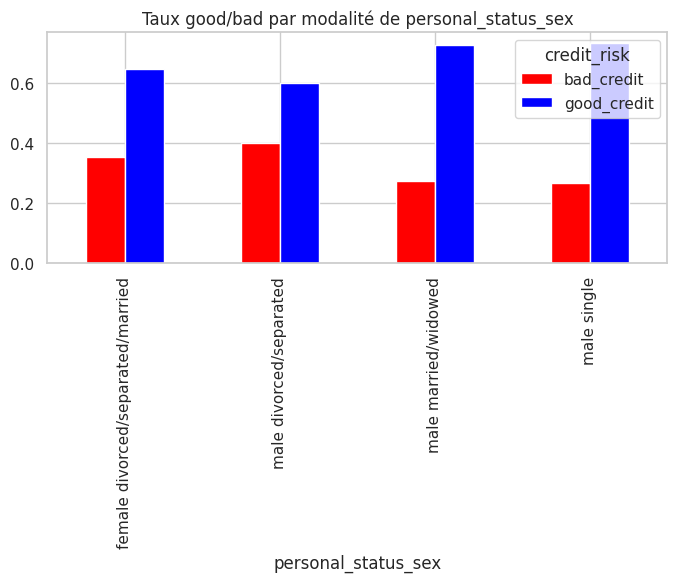

credit_risk,bad_credit,good_credit
personal_status_sex,,
female divorced/separated/married,0.352,0.648
male divorced/separated,0.400,0.600
male married/widowed,0.272,0.728
male single,0.266,0.734


In [37]:
# Crosstab sensible credit_risk x personal_status_sex
crosstab = pd.crosstab(
    df["personal_status_sex"],
    df["credit_risk"],
    normalize="index",).round(3)

fig, ax = plt.subplots(figsize=(8, 3))
crosstab.plot(kind="bar", ax=ax, color=["red", "blue"])
ax.set_title("Taux good/bad par modalité de personal_status_sex")
ax.legend(title="credit_risk")
plt.show()

display(crosstab)

## 3. Audit éthique léger (~1 h)

Déséquilibre cible + **disparate impact** sur au moins 2 variables sensibles.
Règle des 4/5 : `DI < 0.8` ou `> 1.25` → signal.

> *Biais structurels détectés*

**foreign_worker (DI = 0.777)** : les résidents étrangers obtiennent un crédit favorable significativement moins souvent que les non-étrangers. Cependant, l'effective faible (< 50) nous indique un manque de fiabilité.  
**sex_binary (DI=0.896)** : la variable agrégée de `personal_status_sex` ne semble pas déclencher de signal. Cependant, il est important de prendre en compte que le résultat est difficile à interpréter étant donné qu'il est difficile de séparer le genre du statut civil.

⚠️ Pas de mitigation à ce stade — on documente, on alerte. La mitigation,
c'est M7.

In [40]:
# Déséquilibre dela cible
target_dist = df["credit_risk"].value_counts(normalize=True)
display(target_dist.rename("proportion").to_frame())

ratio = target_dist.min() / target_dist.max()
display(f"Ratio minoritaire / majoritaire : {ratio:.2f} - déséquilibre {'modéré' if ratio > 0.3 else 'fort'}")

,proportion
credit_risk,
good_credit,0.7
bad_credit,0.3


'Ratio minoritaire / majoritaire : 0.43 - déséquilibre modéré'

In [7]:
# Fonction disparate 

def di(df: pd.DataFrame, sensitive_col: str, target_col: str, positive_label: str) -> pd.DataFrame:
    """ Calcule le disparate impact pour chaque modalite d'une varaible sensible.
    DI = SR_groupe / SR_max avec SR = P(outcome_positif | groupe)
    Le groupe majoritaire (SR le plus haut) sert de reference implicite : DI_ref = 1.0.
    Regle  des 4/5 : DI < 0.8 ou > 1.25 -> alerte
    """
    grouped = df.groupby(sensitive_col)

    result = pd.DataFrame({
        "effectif": grouped[target_col].count(),
        "selection_rate": grouped[target_col].apply(
            lambda s: (s == positive_label).mean()
        ).round(3)
    })
    sr_max = result["selection_rate"].max()
    result["DI"] = (result["selection_rate"] / sr_max).round(3)

    result["alerte_4/5"] = result["DI"].apply(
        lambda d: "Oui" if d < 0.8 or d > 1.25 else "Non"
    )

    result["fiabilite"] = result["effectif"].apply(
        lambda n: "effective faible (<50)" if n < 50 else "ok"
    )

    return result.sort_values("DI")

In [50]:
# Disparate impact sur foreign_worker :

di_foreign = di(
    df,
    sensitive_col="foreign_worker",
    target_col="credit_risk",
    positive_label="good_credit",
)

display(di_foreign)

di_val_foreign = di_foreign["DI"].min()
display(
    f"DI foreign_worker = {di_val_foreign:.3f} "
    f"{'Signal (DI < 0.8)' if di_val_foreign < 0.8 else 'pas de signal 4/5'}"
)

,effectif,selection_rate,DI,alerte_4/5,fiabilite
foreign_worker,,,,,
yes,963,0.693,0.777,Oui,ok
no,37,0.892,1.000,Non,effective faible (<50)


'DI foreign_worker = 0.777 Signal (DI < 0.8)'

In [53]:
# Disparate impact sur personal_status_sex
# Reconstitution de la colonne sex_binary => attention on supprime le statut marital 
# analyse à effectuer sur 
df["sex_binary"] = df["personal_status_sex"].apply(
    lambda s: "female" if str(s).startswith("female") else "male"
)

display(df["sex_binary"].value_counts().rename("effectif").to_frame())

di_sex = di(
    df,
    sensitive_col="sex_binary",
    target_col="credit_risk",
    positive_label="good_credit",
)

display(di_sex)

di_val_sex = di_sex["DI"].min()

display(
    f"DI sex_binary = {di_val_sex:.3f} "
    f"{'Signal (DI < 0.8)' if di_val_sex < 0.8 else 'pas de signal 4/5'}"
)
df = df.drop(columns=["sex_binary"])



,effectif
sex_binary,
male,690
female,310


,effectif,selection_rate,DI,alerte_4/5,fiabilite
sex_binary,,,,,
female,310,0.648,0.896,Non,ok
male,690,0.723,1.000,Non,ok


'DI sex_binary = 0.896 pas de signal 4/5'

## 4. Choix de prétraitement (~30 min)

Pour chaque feature, décide : numérique (impute + scale), ordinale
(impute + ordinal encoding **avec ordre**), catégorielle (impute + onehot),
ou exclue (justifie).

Remplis les listes `NUMERIC_FEATURES`, `ORDINAL_FEATURES`,
`CATEGORICAL_FEATURES` dans `src/preprocess.py`.

**ORDINAL_FEATURES**  

`checking_account_status` : ordre par solde croissant - compte débiteur, solde faible mais positif, situation faible  
`credit_history` : ordre par fiabilité de remboursement croissante - crédits en souffrance, retards passés, remboursement en cours conformes  
`savings_account` : ordre monétaire croissant - pas d'épargne, seuils de DM croissants  
`employment_since` : ordre par ancienneté croissante - non employé, contrat court, contrat long, ...  
`other_debtors` : ordre par signal de risque décroissant - t

## 5. Industrialisation Pipeline (~1 h 15)

Une fois `src/preprocess.py` complété, fitte le pipeline et sauve-le.

### 🎓 Pourquoi un `Pipeline` ? (définition — la fuite de données)

Tu pourrais imputer/encoder/scaler « à la main » en Pandas. On enferme tout
dans un `Pipeline` parce qu'un préprocesseur **apprend des paramètres sur les
données** : `SimpleImputer` retient une médiane, `StandardScaler` une moyenne
et un écart-type, `OneHotEncoder` la liste des modalités.

**Fuite de données** (*data leakage*) = laisser de l'information du jeu de
**test** influencer la préparation du jeu d'**entraînement** — typiquement
calculer ces paramètres sur *tout* le dataset avant de le splitter. Symptôme :
des scores de validation **anormalement optimistes** qui s'effondrent en prod.

Le `Pipeline` est l'outil qui rend l'étanchéité automatique : un seul `fit` sur
le train propage la discipline à toutes les transformations. **Ici tu n'as pas
de split** (on produit juste un dataset propre) → `fit_transform` sur tout le
dataset est OK. **Réflexe à garder** : *dès qu'un modèle entre en jeu, le
préprocesseur ne se `fit` que sur le train.* → mise en œuvre en **M4-B1**.

In [3]:
import sys
sys.path.append("../src")
from preprocess import build_preprocessor, load_dataset

X, y = load_dataset(RAW_PATH)
preprocessor = build_preprocessor()
X_transformed = preprocessor.fit_transform(X)
print(f"Shape originale : {X.shape}")
print(f"Shape transformée : {X_transformed.shape}")

# Test sur un sous-échantillon
X_sample = X.sample(n=50, random_state=42)
X_sample_t = preprocessor.transform(X_sample)
assert X_sample_t.shape[0] == 50, "Lignes préservées"
assert np.isnan(X_sample_t).sum() == 0, "Aucun NaN"

Shape originale : (1000, 20)
Shape transformée : (1000, 41)


Test validé : lignes préservées et aucun NaN

In [ ]:
import joblib
joblib.dump(preprocessor, "../src/pipeline.joblib", compress=3)

# 5.bis Adapter la pipeline

**Chargement et jointure par position**  
Le fichier `german_credit_supplement.csv` contient 1 colonne `customer_segment`. On joint cette colonne avec le dataset existant.

**Nature de la variable — décision : ordinale**  
Les valeurs `basic < plus < premium < private` correspondent à des niveaux de
service client croissants, corrélés avec le revenu et le patrimoine.

→ `OrdinalEncoder` avec ordre explicite `[basic, plus, premium, private]`.

**Réflexe éthique**  
Un segment commercial corrèle avec la richesse du client : l'utiliser pour
scorer un crédit risque de figer des inégalités socio-économiques préexistantes.

In [5]:
SUPPLEMENT_PATH = DATA_DIR / "german_credit_supplement.csv"

X_sup, y_sup = load_dataset(RAW_PATH, supplement_path=SUPPLEMENT_PATH)

display(f"Shape avec supplément : {X_sup.shape}")

n_missing = X_sup["customer_segment"].isna().sum()
pct_missing = n_missing / len(X_sup) * 100

display(f"Manquants : {n_missing} ({pct_missing:.1f}%)")
display(X_sup["customer_segment"].value_counts(dropna=False))

'Shape avec supplément : (1000, 21)'

'Manquants : 37 (3.7%)'

customer_segment
basic      380
plus       343
premium    158
private     82
NaN         37
Name: count, dtype: int64

In [8]:
# Audit éthique : disparate impact sur customer_segment - segment "premium" ou "private" = groupe favorisé
X_sup_audit = X_sup.copy()
X_sup_audit["segment_binary"] = X_sup_audit["customer_segment"].apply(
    lambda s: "haut" if s in ["premium", "private"] else "bas"
)
X_sup_audit["credit_risk"] = y_sup.map({1: "good_credit", 0: "bad_credit"})

di_segment = di(
    X_sup_audit,
    sensitive_col="segment_binary",
    target_col="credit_risk",
    positive_label="good_credit",
)
display(di_segment)

di_val_seg = di_segment["DI"].min()
display(
    f"DI segment (bas vs haut) = {di_val_seg:.3f} — "
    f"{'Signal (DI < 0.8)' if di_val_seg < 0.8 else 'pas de signal 4/5'}"
)

,effectif,selection_rate,DI,alerte_4/5,fiabilite
segment_binary,,,,,
haut,240,0.262,0.84,Non,ok
bas,760,0.312,1.00,Non,ok


'DI segment (bas vs haut) = 0.840 — pas de signal 4/5'

In [9]:
# Vérification relecture
df_back = pd.read_parquet(CLEAN_PATH)
print(f"Relu : {df_back.shape}, types préservés : {df_back.dtypes.value_counts().to_dict()}")

csv_size = RAW_PATH.stat().st_size / 1024
pq_size = CLEAN_PATH.stat().st_size / 1024
print(f"CSV : {csv_size:.1f} Ko · Parquet : {pq_size:.1f} Ko (compression : {csv_size/pq_size:.1f}x)")

FileNotFoundError: [Errno 2] No such file or directory: '../data/german_credit_clean.parquet'

In [ ]:
# Pipeline sans supplément (déjà fitté en section 5, on récupère sa shape)
preprocessor_base = build_preprocessor(with_supplement=False)
X_base, _ = load_dataset(RAW_PATH)
Xt_base = preprocessor_base.fit_transform(X_base)

# Pipeline avec supplément
preprocessor_sup = build_preprocessor(with_supplement=True)
Xt_sup = preprocessor_sup.fit_transform(X_sup)

display(f"Features sans supplément : {Xt_base.shape[1]}")
display(f"Features avec supplément : {Xt_sup.shape[1]}")
display(f"Différence : +{Xt_sup.shape[1] - Xt_base.shape[1]}")

# Vérifications
assert Xt_sup.shape[0] == len(X_sup), "Lignes préservées"
assert Xt_sup.shape[1] == Xt_base.shape[1] + 1, "+1 feature attendue"
assert np.isnan(Xt_sup).sum() == 0, "Aucun NaN après imputation"

display("T5 bis OK")

## 6. Persistance Parquet + datasheet (~45 min)

Sauve le dataset propre en Parquet (pyarrow) et complète `datasheet.md`
(7 sections Gebru, schéma documenté dans *Composition*).

In [ ]:
# TODO — sauve un DataFrame *propre* (post-imputation si tu veux) en Parquet :
# df_clean.to_parquet(CLEAN_PATH, engine="pyarrow", compression="snappy")

## 7. Synthèse audit.md (~30 min)

Complète `audit.md` : verdict qualité (3-5 problèmes) + verdict éthique
(2-3 alertes) + recommandations. Lisible par le DPO Klaus Eichmann
(pas de jargon scikit-learn).